# Laboratorio 3 - Clasificación: SmartAlpes
## Paso 2: Limpieza y preparación de los datos

En este paso se aplican las decisiones de limpieza y preparación identificadas durante la exploración (Paso 1). Cada decisión se justifica con base en los hallazgos previos y en los requerimientos de los modelos de regresión logística y árboles de decisión que se construirán en los pasos siguientes.

### 1. Importación de librerías y carga de datos

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             f1_score, precision_score, recall_score)
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# ── Carga de datos ──────────────────────────────────────────────────────────
df_raw = pd.read_csv('Datos_Laboratorio3.csv', sep=';', encoding='latin-1')

# Corrección de nombres de columna (error tipográfico + codificación especial)
df_raw.rename(columns={
    'Gnereo':               'Genero',
    'Horas_sue\xf1o':       'Horas_sueno',
    'Plan_nutrici\xf3n':    'Plan_nutricion'
}, inplace=True)

print("Dataset cargado:", df_raw.shape)
df_raw.head(3)

Dataset cargado: (9698, 26)


,Edad,Genero,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutricion
0,60,Masculino,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,...,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,...,0,0.0,0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
2,43,Masculino,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.34,104.9,3050,2.53,Bajo,Basico


### 2. Trabajo sobre una copia del dataset

Se trabaja sobre una copia para preservar los datos originales y poder comparar antes/después de cada transformación.

In [2]:
df = df_raw.copy()
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")

Filas: 9698  |  Columnas: 26


### 3. Corrección de inconsistencias lógicas

**Hallazgo (Paso 1):** Las columnas `Cigarrillos_dia` y `Alcohol_semana` deberían ser 0 cuando sus indicadores binarios (`Fumador` y `Alcohol`) son 0. Se verifican y corrigen estas inconsistencias.

**Justificación:** Un valor de `Cigarrillos_dia > 0` con `Fumador = 0` es un error de registro. Corregirlo evita que el modelo aprenda patrones falsos.

In [3]:
# Inconsistencias: Fumador=0 pero Cigarrillos_dia > 0
inc_fum = ((df['Fumador'] == 0) & (df['Cigarrillos_dia'] > 0)).sum()
print(f"Registros con Fumador=0 y Cigarrillos_dia > 0: {inc_fum}")

# Inconsistencias: Alcohol=0 pero Alcohol_semana > 0
inc_alc = ((df['Alcohol'] == 0) & (df['Alcohol_semana'] > 0)).sum()
print(f"Registros con Alcohol=0 y Alcohol_semana > 0:  {inc_alc}")

# Corrección: forzar a 0 donde el indicador binario es 0
df.loc[df['Fumador'] == 0, 'Cigarrillos_dia'] = 0
df.loc[df['Alcohol'] == 0, 'Alcohol_semana']  = 0

# Verificación
print("\nTras corrección:")
print(f"  Fumador=0 y Cigarrillos_dia > 0: {((df['Fumador']==0) & (df['Cigarrillos_dia']>0)).sum()}")
print(f"  Alcohol=0 y Alcohol_semana > 0:  {((df['Alcohol']==0) & (df['Alcohol_semana']>0)).sum()}")

Registros con Fumador=0 y Cigarrillos_dia > 0: 0
Registros con Alcohol=0 y Alcohol_semana > 0:  0

Tras corrección:
  Fumador=0 y Cigarrillos_dia > 0: 0
  Alcohol=0 y Alcohol_semana > 0:  0


### 4. Tratamiento de valores faltantes

**Hallazgo (Paso 1):** La columna `Peso` tiene valores faltantes. Las demás columnas no presentan valores nulos en el conjunto de entrenamiento.

**Decisión:** Imputar `Peso` utilizando la mediana segmentada por `Genero`, ya que el peso promedio difiere significativamente entre grupos de género. Esta estrategia es más precisa que la mediana global y evita introducir sesgos.

**Justificación:** La imputación por mediana es robusta frente a outliers (presentes en `Peso`, como se vio en el Paso 1). Imputar por la mediana del grupo es preferible a imputar globalmente cuando existe una variable altamente correlacionada con la variable con datos faltantes.

In [4]:
print("Valores faltantes antes de imputación:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Imputación de Peso por mediana agrupada por Genero
mediana_peso = df.groupby('Genero')['Peso'].median()
print("\nMediana de Peso por Genero:")
print(mediana_peso)

def imputar_peso(row):
    if pd.isna(row['Peso']):
        return mediana_peso.get(row['Genero'], df['Peso'].median())
    return row['Peso']

df['Peso'] = df.apply(imputar_peso, axis=1)

print(f"\nValores faltantes en Peso tras imputación: {df['Peso'].isnull().sum()}")
print(f"Total de valores faltantes en el dataset:   {df.isnull().sum().sum()}")

Valores faltantes antes de imputación:
Peso    11
dtype: int64

Mediana de Peso por Genero:
Genero
Femenino     93.00
Masculino    92.50
Otro         89.25
Name: Peso, dtype: float64

Valores faltantes en Peso tras imputación: 0
Total de valores faltantes en el dataset:   0


### 5. Análisis de redundancia: Peso, Altura y BMI

**Hallazgo (Paso 1):** Las tres variables están matemáticamente relacionadas: $BMI = \frac{Peso}{Altura^2}$. Incluir las tres puede generar multicolinealidad en la regresión logística.

**Decisión:** Se conservan `Peso`, `Altura` y `BMI`. Aunque existe relación matemática, en la práctica cada una aporta información útil al modelo: `BMI` captura el índice combinado, mientras que `Peso` y `Altura` de forma individual pueden ser predictores relevantes. Además, los árboles de decisión no sufren de multicolinealidad. En el pipeline de regresión logística se aplicará escalado que reduce el efecto de la correlación.

**Verificación de correlación:**

Matriz de correlación Peso – Altura – BMI:


,Peso,Altura,BMI
Peso,1.000,-0.007,0.843
Altura,-0.007,1.000,-0.517
BMI,0.843,-0.517,1.000


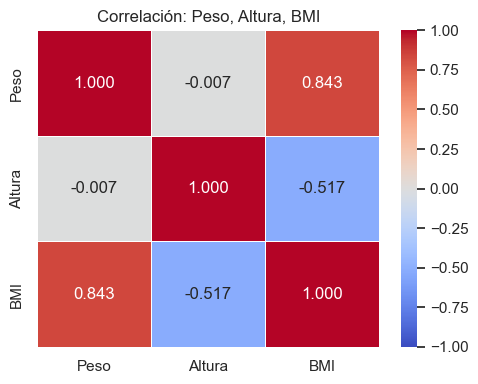


Decisión: se conservan las tres columnas. El escalado y la regularización
en el pipeline de regresión logística mitigarán el efecto de la colinealidad.


In [5]:
corr_bmi = df[['Peso', 'Altura', 'BMI']].corr().round(3)
print("Matriz de correlación Peso – Altura – BMI:")
display(corr_bmi)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_bmi, annot=True, fmt='.3f', cmap='coolwarm', ax=ax,
            vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Correlación: Peso, Altura, BMI')
plt.tight_layout()
plt.show()

print("\nDecisión: se conservan las tres columnas. El escalado y la regularización")
print("en el pipeline de regresión logística mitigarán el efecto de la colinealidad.")

### 6. Tratamiento de outliers

**Hallazgo (Paso 1):** Variables como `BMI`, `Cigarrillos_dia` y `Alcohol_semana` contienen outliers. Estos no son errores sino perfiles extremos válidos de usuarios del gimnasio.

**Decisión:** No se eliminan los outliers. En cambio:
- Para la **regresión logística**, se usará `RobustScaler` en el pipeline, que escala usando la mediana y el IQR, siendo insensible a valores extremos.
- Para los **árboles de decisión**, no se requiere escalado; los outliers no afectan el proceso de división del árbol.

A continuación se verifica la magnitud de los outliers para confirmar que son valores plausibles:

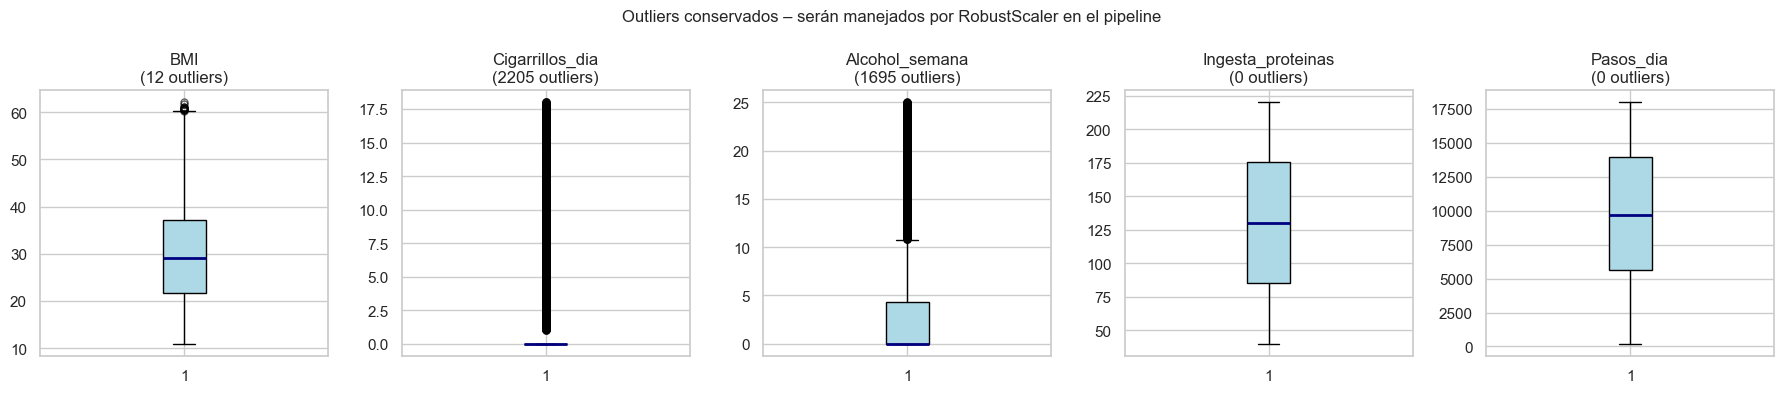

In [6]:
vars_outlier = ['BMI', 'Cigarrillos_dia', 'Alcohol_semana', 'Ingesta_proteinas', 'Pasos_dia']

fig, axes = plt.subplots(1, len(vars_outlier), figsize=(18, 4))
for i, col in enumerate(vars_outlier):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='navy', linewidth=2),
                    flierprops=dict(marker='o', color='crimson', markersize=5, alpha=0.6))
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    axes[i].set_title(f'{col}\n({n_out} outliers)')

fig.suptitle('Outliers conservados – serán manejados por RobustScaler en el pipeline', fontsize=12)
plt.tight_layout()
plt.show()

### 7. Definición de features y variables objetivo

Se separan las variables predictoras (features) de las variables objetivo. Se excluyen `Plan_entrenamiento` y `Plan_nutricion` del conjunto de features.

In [7]:
TARGET_ENT = 'Plan_entrenamiento'
TARGET_NUT = 'Plan_nutricion'

# Columnas de entrada (se excluyen ambas variables objetivo)
FEATURE_COLS = [c for c in df.columns if c not in [TARGET_ENT, TARGET_NUT]]

# Variables numéricas continuas / discretas (sin las binarias que ya son 0/1)
COLS_NUM = ['Edad', 'Peso', 'Altura', 'BMI', 'Horas_sueno',
            'Cigarrillos_dia', 'Alcohol_semana', 'Score_micronutrientes',
            'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua',
            'Cantidad_equipo', 'Tiempo_disponible']

# Variables binarias (ya codificadas como 0/1 – no requieren procesamiento adicional)
COLS_BIN = ['Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Alcohol']

# Variables categóricas nominales (sin orden natural)
COLS_CAT_NOM = ['Genero', 'Objetivo', 'Condicion_salud',
                'Dieta_preferida', 'Entrenamiento_preferido']

# Variables ordinales con orden definido
COLS_CAT_ORD = ['Nivel_Actividad', 'Nivel_experiencia']

print("Features totales:", len(FEATURE_COLS))
print("  - Numéricas (continuas/discretas):", COLS_NUM)
print("  - Binarias (0/1):", COLS_BIN)
print("  - Categóricas nominales:", COLS_CAT_NOM)
print("  - Categóricas ordinales:", COLS_CAT_ORD)

Features totales: 24
  - Numéricas (continuas/discretas): ['Edad', 'Peso', 'Altura', 'BMI', 'Horas_sueno', 'Cigarrillos_dia', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua', 'Cantidad_equipo', 'Tiempo_disponible']
  - Binarias (0/1): ['Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Alcohol']
  - Categóricas nominales: ['Genero', 'Objetivo', 'Condicion_salud', 'Dieta_preferida', 'Entrenamiento_preferido']
  - Categóricas ordinales: ['Nivel_Actividad', 'Nivel_experiencia']


### 8. División train / test

**Decisión:** Se usa un split 80 % / 20 % con `stratify` sobre `Plan_entrenamiento` para garantizar que ambas particiones mantengan la misma proporción de clases.

**Justificación:** Dado el desbalance de clases observado en el Paso 1, la estratificación es fundamental para que el conjunto de test sea representativo y las métricas de evaluación sean confiables.

In [8]:
X = df[FEATURE_COLS]
y_ent = df[TARGET_ENT]
y_nut = df[TARGET_NUT]

X_train, X_test, y_ent_train, y_ent_test, y_nut_train, y_nut_test = train_test_split(
    X, y_ent, y_nut,
    test_size=0.20,
    random_state=42,
    stratify=y_ent   # estratificar por Plan_entrenamiento
)

print(f"Train:  {X_train.shape[0]} registros  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test:   {X_test.shape[0]}  registros  ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verificar distribución de clases en train y test
print("\nDistribución Plan_entrenamiento – Train:")
print((y_ent_train.value_counts(normalize=True)*100).round(1).to_string())
print("\nDistribución Plan_entrenamiento – Test:")
print((y_ent_test.value_counts(normalize=True)*100).round(1).to_string())

Train:  7758 registros  (80.0%)
Test:   1940  registros  (20.0%)

Distribución Plan_entrenamiento – Train:
Plan_entrenamiento
Ninguno    39.2
Medio      30.4
Bajo       23.6
Alto        6.8

Distribución Plan_entrenamiento – Test:
Plan_entrenamiento
Ninguno    39.3
Medio      30.4
Bajo       23.6
Alto        6.8


### 9. Construcción del pipeline de preprocesamiento

Se construye un `ColumnTransformer` que aplica transformaciones diferenciadas según el tipo de variable:

| Tipo de variable | Transformación | Justificación |
|---|---|---|
| Numéricas continuas/discretas | `SimpleImputer(median)` + `RobustScaler` | La imputación por mediana es robusta; RobustScaler maneja outliers sin eliminarlos |
| Binarias (0/1) | Pasar tal cual (`passthrough`) | Ya están en escala binaria; no requieren transformación |
| Categóricas nominales | `SimpleImputer(most_frequent)` + `OneHotEncoder` | OHE elimina el supuesto de orden en variables sin jerarquía |
| Categóricas ordinales | `OrdinalEncoder` con orden definido | Se preserva el orden real: Bajo < Moderado < Alto; Principiante < Intermedio < Avanzado |

**Nota sobre el escalado:** Para la **regresión logística** se usa `RobustScaler` porque es sensible a la escala y los outliers afectan la convergencia. Para los **árboles de decisión** el escalado no es necesario, pero el mismo pipeline es reutilizable.

In [9]:
# Órdenes para variables ordinales
orden_nivel_actividad  = [['Bajo', 'Moderado', 'Alto']]
orden_nivel_experiencia = [['Principiante', 'Intermedio', 'Avanzado']]

# Pipeline por tipo
pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

pipe_cat_nom = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

pipe_ord_actividad = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('oe',      OrdinalEncoder(categories=orden_nivel_actividad,
                               handle_unknown='use_encoded_value', unknown_value=-1))
])

pipe_ord_experiencia = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('oe',      OrdinalEncoder(categories=orden_nivel_experiencia,
                               handle_unknown='use_encoded_value', unknown_value=-1))
])

# ColumnTransformer que une todas las transformaciones
preprocessor = ColumnTransformer(transformers=[
    ('num',         pipe_num,            COLS_NUM),
    ('bin',         'passthrough',       COLS_BIN),
    ('cat_nom',     pipe_cat_nom,        COLS_CAT_NOM),
    ('ord_act',     pipe_ord_actividad,  ['Nivel_Actividad']),
    ('ord_exp',     pipe_ord_experiencia,['Nivel_experiencia']),
], remainder='drop')

print("Preprocessor construido correctamente.")
print(f"\nColumnas de entrada al preprocessor: {X_train.shape[1]}")
preprocessor

Preprocessor construido correctamente.

Columnas de entrada al preprocessor: 24


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['Edad', 'Peso', 'Altura', 'BMI',
                                  'Horas_sueno', 'Cigarrillos_dia',
                                  'Alcohol_semana', 'Score_micronutrientes',
                                  'Ingesta_proteinas', 'Pasos_dia',
                                  'Ingesta_agua', 'Cantidad_equipo',
                                  'Tiempo_disponible']),
                                ('bin', 'passthrough',
                                 ['Tiene_ale...
                                                  OrdinalEncoder(categories=[['Bajo',
                                                                              'Moderado',
                                                                              'Alto']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['Nivel_Actividad']),
                                ('ord_exp',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('oe',
                                                  OrdinalEncoder(categories=[['Principiante',
                                                                              'Intermedio',
                                                                              'Avanzado']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['Nivel_experiencia'])])

## Paso 3: Modelos de Regresión Logística

Se desarrollan dos modelos de regresión logística —uno para `Plan_entrenamiento` y otro para `Plan_nutricion`— integrando el preprocesamiento y el clasificador en un **pipeline** reproducible. La búsqueda de hiperparámetros se realiza con **GridSearchCV** y validación cruzada estratificada, explorando el tipo de regularización (`l1`, `l2`, `elasticnet`), el solver y la intensidad de regularización `C`.

### 1. Arquitectura del pipeline

Cada modelo tiene la siguiente estructura:

```
Pipeline
├── prep  ── ColumnTransformer (preprocesamiento del Paso 2)
└── clf   ── LogisticRegression(max_iter=1000)
```

#### Grilla de hiperparámetros explorada

La compatibilidad entre `penalty` y `solver` en scikit-learn impone restricciones:

| Penalty | Solvers compatibles |
|---|---|
| `l2` | `lbfgs`, `liblinear`, `saga` |
| `l1` | `liblinear`, `saga` |
| `elasticnet` | `saga` (requiere `l1_ratio`) |

Se definen **tres sublistas** en el `param_grid` para respetar estas restricciones. La métrica de optimización es **F1-weighted** (robusta ante desbalance de clases). La validación cruzada usa **StratifiedKFold(5)** para preservar la distribución de clases 

In [12]:
# Grilla de hiperparámetros (compatibilidad penalty-solver garantizada)
param_grid_rl = [
    # ── L2: compatible con lbfgs, liblinear, saga ──────────────────────────
    {
        'clf__penalty': ['l2'],
        'clf__solver':  ['lbfgs', 'liblinear', 'saga'],
        'clf__C':       [0.01, 0.1, 1, 10, 100],
    },
    # ── L1: solo liblinear y saga ──────────────────────────────────────────
    {
        'clf__penalty': ['l1'],
        'clf__solver':  ['liblinear', 'saga'],
        'clf__C':       [0.01, 0.1, 1, 10, 100],
    },
    # ── Elasticnet: solo saga, requiere l1_ratio ───────────────────────────
    {
        'clf__penalty':   ['elasticnet'],
        'clf__solver':    ['saga'],
        'clf__C':         [0.01, 0.1, 1, 10, 100],
        'clf__l1_ratio':  [0.25, 0.5, 0.75],
    },
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

n_combinaciones = (3*5) + (2*5) + (1*5*3)
print(f"Combinaciones totales exploradas: {n_combinaciones}")
print("Métrica de optimización: F1-weighted")

Combinaciones totales exploradas: 40
Métrica de optimización: F1-weighted


### 2. Modelo para `Plan_entrenamiento`
#### 2.1 Búsqueda de hiperparámetros con GridSearchCV

In [13]:
pipeline_ent = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(max_iter=1000, random_state=42))
])

gs_ent = GridSearchCV(
    pipeline_ent,
    param_grid_rl,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    refit=True
)

print("Entrenando GridSearchCV para Plan_entrenamiento...")
gs_ent.fit(X_train, y_ent_train)

print(f"\n{'='*55}")
print(f"  Mejores hiperparámetros encontrados:")
for k, v in gs_ent.best_params_.items():
    print(f"    {k:30s}: {v}")
print(f"\n  F1-weighted (CV, media): {gs_ent.best_score_:.4f}")
print(f"{'='*55}")

Entrenando GridSearchCV para Plan_entrenamiento...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

  Mejores hiperparámetros encontrados:
    clf__C                        : 0.1
    clf__l1_ratio                 : 0.5
    clf__penalty                  : elasticnet
    clf__solver                   : saga

  F1-weighted (CV, media): 0.6557


In [14]:
# Top 10 combinaciones de la búsqueda
cv_results_ent = pd.DataFrame(gs_ent.cv_results_)
cols_vis = ['rank_test_score', 'param_clf__penalty', 'param_clf__solver',
            'param_clf__C', 'param_clf__l1_ratio',
            'mean_test_score', 'std_test_score']

top10_ent = (cv_results_ent[cols_vis]
             .sort_values('rank_test_score')
             .head(10)
             .reset_index(drop=True))

print("Top 10 combinaciones – Plan_entrenamiento:")
display(top10_ent.round(4))

Top 10 combinaciones – Plan_entrenamiento:


,rank_test_score,param_clf__penalty,param_clf__solver,param_clf__C,param_clf__l1_ratio,mean_test_score,std_test_score
0,1,elasticnet,saga,0.1,0.50,0.6557,0.0086
1,2,l1,saga,0.1,NaN,0.6551,0.0077
2,3,elasticnet,saga,0.1,0.75,0.6541,0.0077
3,4,elasticnet,saga,0.1,0.25,0.6526,0.0104
4,5,elasticnet,saga,1.0,0.50,0.6516,0.0101
5,6,l2,saga,1.0,NaN,0.6512,0.0101
6,7,elasticnet,saga,1.0,0.25,0.6511,0.0105
7,8,elasticnet,saga,1.0,0.75,0.6506,0.0099
8,9,l2,lbfgs,1.0,NaN,0.6506,0.0107
9,10,l1,saga,1.0,NaN,0.6503,0.0096


#### 2.2 Evaluación del mejor modelo sobre el conjunto de test

In [15]:
best_ent = gs_ent.best_estimator_
y_pred_ent = best_ent.predict(X_test)

print("=== Reporte de clasificación – Plan_entrenamiento (Test) ===\n")
print(classification_report(y_ent_test, y_pred_ent))

# Métricas resumen
f1_w_ent  = f1_score(y_ent_test, y_pred_ent, average='weighted')
f1_m_ent  = f1_score(y_ent_test, y_pred_ent, average='macro')
prec_ent  = precision_score(y_ent_test, y_pred_ent, average='weighted')
rec_ent   = recall_score(y_ent_test, y_pred_ent, average='weighted')

print(f"F1-weighted : {f1_w_ent:.4f}")
print(f"F1-macro    : {f1_m_ent:.4f}")
print(f"Precisión   : {prec_ent:.4f}")
print(f"Recall      : {rec_ent:.4f}")

=== Reporte de clasificación – Plan_entrenamiento (Test) ===

              precision    recall  f1-score   support

        Alto       0.90      0.76      0.82       131
        Bajo       0.44      0.28      0.35       458
       Medio       0.66      0.77      0.71       589
     Ninguno       0.75      0.84      0.79       762

    accuracy                           0.68      1940
   macro avg       0.69      0.66      0.67      1940
weighted avg       0.66      0.68      0.66      1940

F1-weighted : 0.6642
F1-macro    : 0.6679
Precisión   : 0.6608
Recall      : 0.6809


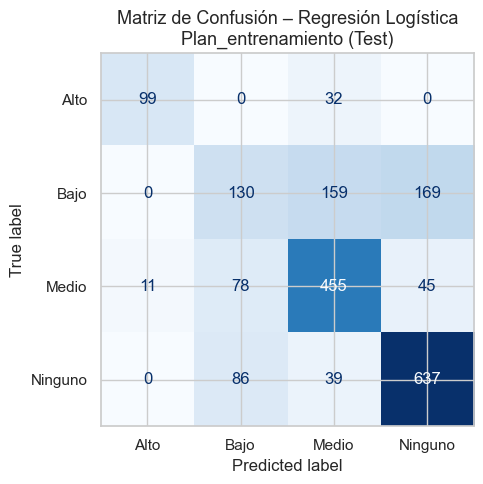

In [16]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_ent_test, y_pred_ent,
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Matriz de Confusión – Regresión Logística\nPlan_entrenamiento (Test)',
             fontsize=13)
plt.tight_layout()
plt.show()

### 3. Modelo para `Plan_nutricion`
#### 3.1 Búsqueda de hiperparámetros con GridSearchCV

Se reutiliza la misma grilla y estrategia de validación cruzada. El preprocesador se reemplaza por una instancia fresca (clonada) para evitar que el ajuste previo del Paso 3 filtre información al nuevo modelo.

In [18]:
pipeline_nut = Pipeline([
    ('prep', clone(preprocessor)),            # instancia fresca del preprocesador
    ('clf',  LogisticRegression(max_iter=1000, random_state=42))
])

gs_nut = GridSearchCV(
    pipeline_nut,
    param_grid_rl,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    refit=True
)

print("Entrenando GridSearchCV para Plan_nutricion...")
gs_nut.fit(X_train, y_nut_train)

print(f"\n{'='*55}")
print(f"  Mejores hiperparámetros encontrados:")
for k, v in gs_nut.best_params_.items():
    print(f"    {k:30s}: {v}")
print(f"\n  F1-weighted (CV, media): {gs_nut.best_score_:.4f}")
print(f"{'='*55}")

Entrenando GridSearchCV para Plan_nutricion...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

  Mejores hiperparámetros encontrados:
    clf__C                        : 100
    clf__penalty                  : l2
    clf__solver                   : lbfgs

  F1-weighted (CV, media): 0.8234


In [19]:
# Top 10 combinaciones de la búsqueda
cv_results_nut = pd.DataFrame(gs_nut.cv_results_)
top10_nut = (cv_results_nut[cols_vis]
             .sort_values('rank_test_score')
             .head(10)
             .reset_index(drop=True))

print("Top 10 combinaciones – Plan_nutricion:")
display(top10_nut.round(4))

Top 10 combinaciones – Plan_nutricion:


,rank_test_score,param_clf__penalty,param_clf__solver,param_clf__C,param_clf__l1_ratio,mean_test_score,std_test_score
0,1,l2,lbfgs,100.0,NaN,0.8234,0.0082
1,2,l1,saga,10.0,NaN,0.8233,0.0081
2,3,elasticnet,saga,10.0,0.75,0.8232,0.0081
3,4,elasticnet,saga,100.0,0.75,0.8230,0.0080
4,5,elasticnet,saga,100.0,0.25,0.8229,0.0080
5,5,l2,saga,100.0,NaN,0.8229,0.0080
6,5,elasticnet,saga,100.0,0.50,0.8229,0.0080
7,8,l1,saga,100.0,NaN,0.8229,0.0080
8,9,l1,saga,1.0,NaN,0.8225,0.0081
9,10,elasticnet,saga,1.0,0.75,0.8223,0.0078


### 3.2 Evaluación del mejor modelo sobre el conjunto de test

In [20]:
best_nut = gs_nut.best_estimator_
y_pred_nut = best_nut.predict(X_test)

print("=== Reporte de clasificación – Plan_nutricion (Test) ===\n")
print(classification_report(y_nut_test, y_pred_nut))

f1_w_nut  = f1_score(y_nut_test, y_pred_nut, average='weighted')
f1_m_nut  = f1_score(y_nut_test, y_pred_nut, average='macro')
prec_nut  = precision_score(y_nut_test, y_pred_nut, average='weighted')
rec_nut   = recall_score(y_nut_test, y_pred_nut, average='weighted')

print(f"F1-weighted : {f1_w_nut:.4f}")
print(f"F1-macro    : {f1_m_nut:.4f}")
print(f"Precisión   : {prec_nut:.4f}")
print(f"Recall      : {rec_nut:.4f}")

=== Reporte de clasificación – Plan_nutricion (Test) ===

               precision    recall  f1-score   support

   Balanceado       0.85      0.87      0.86       871
       Basico       0.72      0.68      0.70       482
Especializado       0.69      0.63      0.66       105
     Sin plan       0.88      0.90      0.89       482

     accuracy                           0.82      1940
    macro avg       0.78      0.77      0.78      1940
 weighted avg       0.82      0.82      0.82      1940

F1-weighted : 0.8164
F1-macro    : 0.7770
Precisión   : 0.8153
Recall      : 0.8180


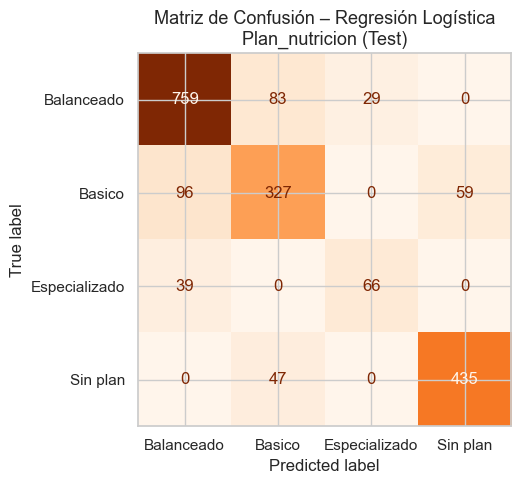

In [21]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_nut_test, y_pred_nut,
    ax=ax, colorbar=False, cmap='Oranges'
)
ax.set_title('Matriz de Confusión – Regresión Logística\nPlan_nutricion (Test)',
             fontsize=13)
plt.tight_layout()
plt.show()

### 4. Resumen comparativo de los mejores modelos

Se consolidan los hiperparámetros seleccionados y las métricas sobre el conjunto de test para ambos objetivos.

=== Resumen de modelos de Regresión Logística ===



,Objetivo,Penalty,Solver,C,l1_ratio,F1-weighted (CV),F1-weighted (Test),F1-macro (Test),Precisión (Test),Recall (Test)
0,Plan_entrenamiento,elasticnet,saga,0.1,0.5,0.6557,0.6642,0.6679,0.6608,0.6809
1,Plan_nutricion,l2,lbfgs,100.0,-,0.8234,0.8164,0.7770,0.8153,0.8180


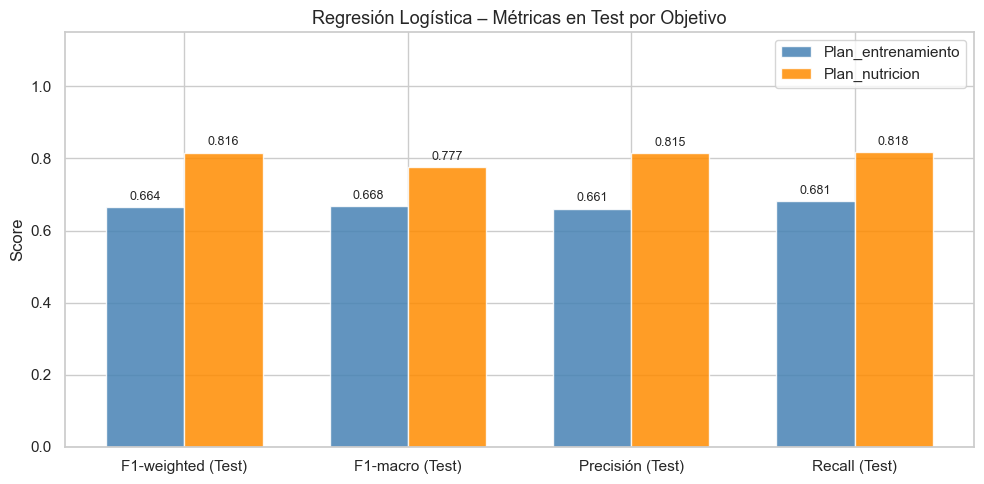

In [22]:
def _get_param(gs, key, default='-'):
    return gs.best_params_.get(key, default)

resumen = pd.DataFrame({
    'Objetivo':          ['Plan_entrenamiento', 'Plan_nutricion'],
    'Penalty':           [_get_param(gs_ent, 'clf__penalty'),
                          _get_param(gs_nut, 'clf__penalty')],
    'Solver':            [_get_param(gs_ent, 'clf__solver'),
                          _get_param(gs_nut, 'clf__solver')],
    'C':                 [_get_param(gs_ent, 'clf__C'),
                          _get_param(gs_nut, 'clf__C')],
    'l1_ratio':          [_get_param(gs_ent, 'clf__l1_ratio'),
                          _get_param(gs_nut, 'clf__l1_ratio')],
    'F1-weighted (CV)':  [round(gs_ent.best_score_, 4),
                          round(gs_nut.best_score_, 4)],
    'F1-weighted (Test)':[round(f1_w_ent, 4), round(f1_w_nut, 4)],
    'F1-macro (Test)':   [round(f1_m_ent, 4), round(f1_m_nut, 4)],
    'Precisión (Test)':  [round(prec_ent, 4), round(prec_nut, 4)],
    'Recall (Test)':     [round(rec_ent, 4),  round(rec_nut, 4)],
})

print("=== Resumen de modelos de Regresión Logística ===\n")
display(resumen)

# Gráfico comparativo de métricas en test
metricas = ['F1-weighted (Test)', 'F1-macro (Test)', 'Precisión (Test)', 'Recall (Test)']
x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2,
               resumen.loc[resumen['Objetivo']=='Plan_entrenamiento', metricas].values[0],
               width, label='Plan_entrenamiento', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2,
               resumen.loc[resumen['Objetivo']=='Plan_nutricion', metricas].values[0],
               width, label='Plan_nutricion', color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Regresión Logística – Métricas en Test por Objetivo', fontsize=13)
ax.legend(fontsize=11)
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()